## Customer Churn Analysis

In [2]:
import sys
!{sys.executable} -m pip install xgboost shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df= pd.read_csv(r'D:\Projects\15\4.Customer_Churn_Prediction\data\train.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(df.head())

Shape: (440833, 12)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Missing values:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Sp

In [5]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing values (only 1 row affected)
df = df.dropna()

# Drop CustomerID — not a feature, just an identifier
df = df.drop('CustomerID', axis=1)

print(f"\nShape after cleaning: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Missing values before cleaning:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Shape after cleaning: (440832, 11)

Churn distribution:
Churn
1.0    56.7
0.0    43.3
Name: proportion, dtype: float64


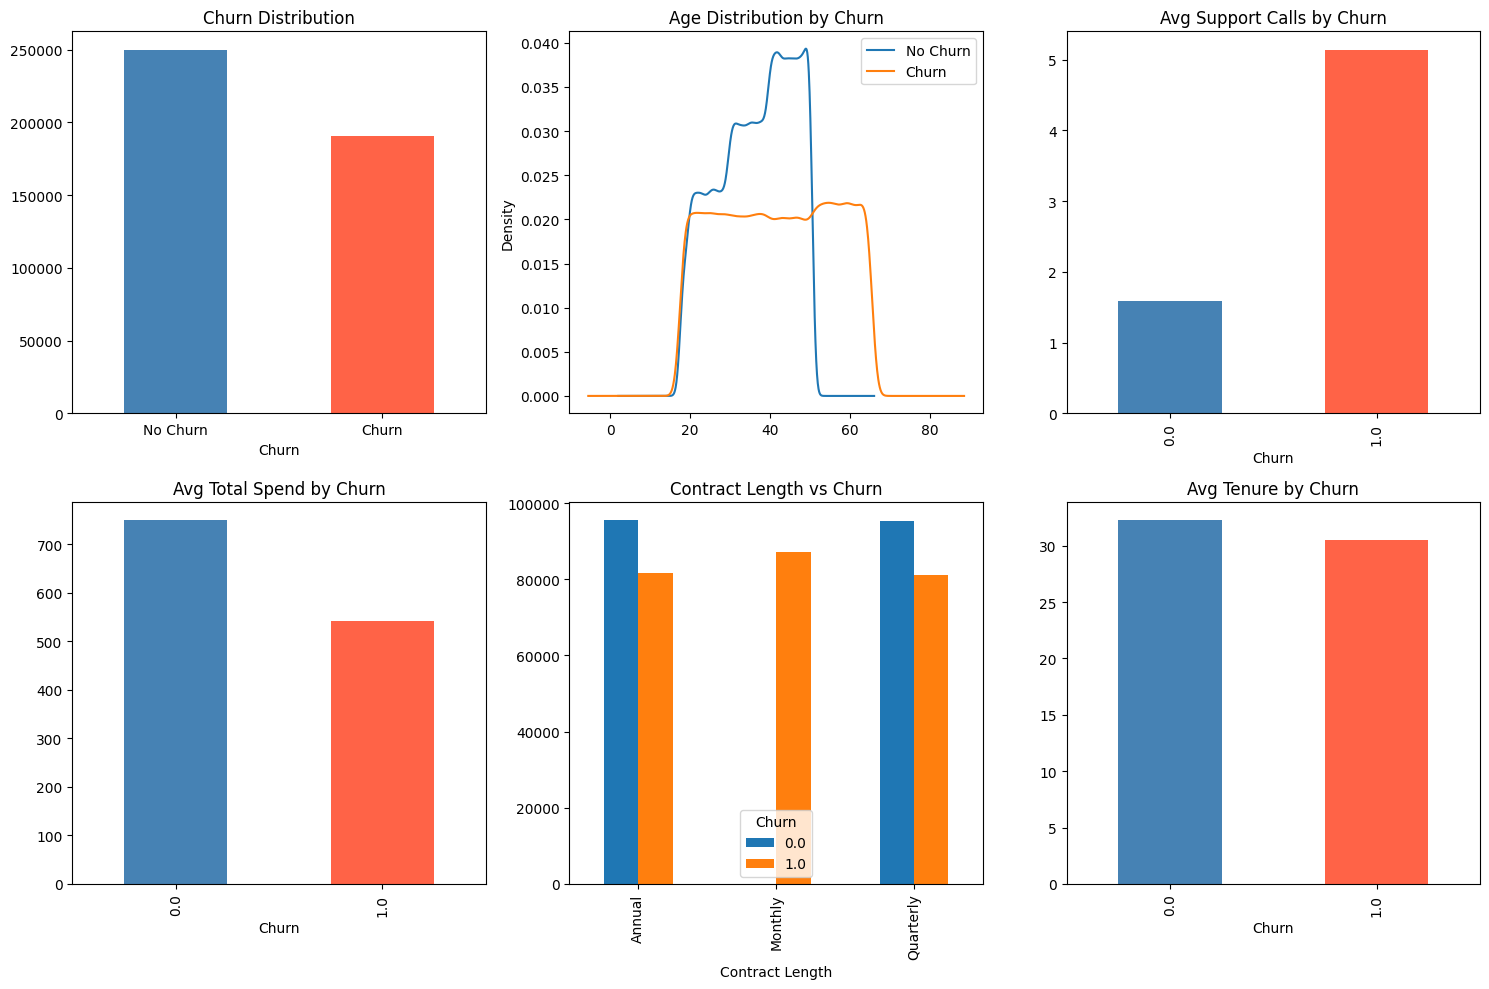

EDA plots saved!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# 2. Age distribution by churn
df.groupby('Churn')['Age'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('Age Distribution by Churn')
axes[0,1].legend(['No Churn', 'Churn'])

# 3. Support Calls by churn
df.groupby('Churn')['Support Calls'].mean().plot(kind='bar', ax=axes[0,2], color=['steelblue','tomato'])
axes[0,2].set_title('Avg Support Calls by Churn')

# 4. Total Spend by churn
df.groupby('Churn')['Total Spend'].mean().plot(kind='bar', ax=axes[1,0], color=['steelblue','tomato'])
axes[1,0].set_title('Avg Total Spend by Churn')

# 5. Contract Length vs Churn
df.groupby(['Contract Length','Churn']).size().unstack().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Contract Length vs Churn')

# 6. Tenure by churn
df.groupby('Churn')['Tenure'].mean().plot(kind='bar', ax=axes[1,2], color=['steelblue','tomato'])
axes[1,2].set_title('Avg Tenure by Churn')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [7]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded:")
print(df[cat_cols].head())

# Define features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Categorical columns encoded:
   Gender  Subscription Type  Contract Length
0       0                  2                0
1       0                  0                1
2       0                  0                2
3       1                  2                1
4       1                  0                1

Features shape: (440832, 10)
Target shape: (440832,)

Feature columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nChurn distribution in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Churn distribution in test: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done!")

Training set: (352665, 10)
Test set: (88167, 10)

Churn distribution in train: {1.0: 0.567, 0.0: 0.433}
Churn distribution in test: {1.0: 0.567, 0.0: 0.433}

Scaling done!


In [9]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    # Evaluate
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        'AUC-ROC': round(auc, 4),
        'Precision': round(report['1.0']['precision'], 4),
        'Recall': round(report['1.0']['recall'], 4),
        'F1': round(report['1.0']['f1-score'], 4)
    }
    print(f"{name} — AUC: {auc:.4f}")

print("\n--- Model Comparison ---")
results_df = pd.DataFrame(results).T
print(results_df)

Training Logistic Regression...
Logistic Regression — AUC: 0.9281
Training Random Forest...
Random Forest — AUC: 1.0000
Training XGBoost...
XGBoost — AUC: 1.0000

--- Model Comparison ---
                     AUC-ROC  Precision  Recall      F1
Logistic Regression   0.9281     0.8787  0.8555  0.8669
Random Forest         1.0000     0.9999  0.9996  0.9998
XGBoost               1.0000     1.0000  0.9999  0.9999


In [10]:
# Check feature correlations with target
correlations = df.corr()['Churn'].sort_values(ascending=False)
print(correlations)

Churn                1.000000
Support Calls        0.574267
Payment Delay        0.312129
Age                  0.218394
Last Interaction     0.149616
Contract Length     -0.000093
Subscription Type   -0.017181
Usage Frequency     -0.046101
Tenure              -0.051919
Gender              -0.175395
Total Spend         -0.429355
Name: Churn, dtype: float64


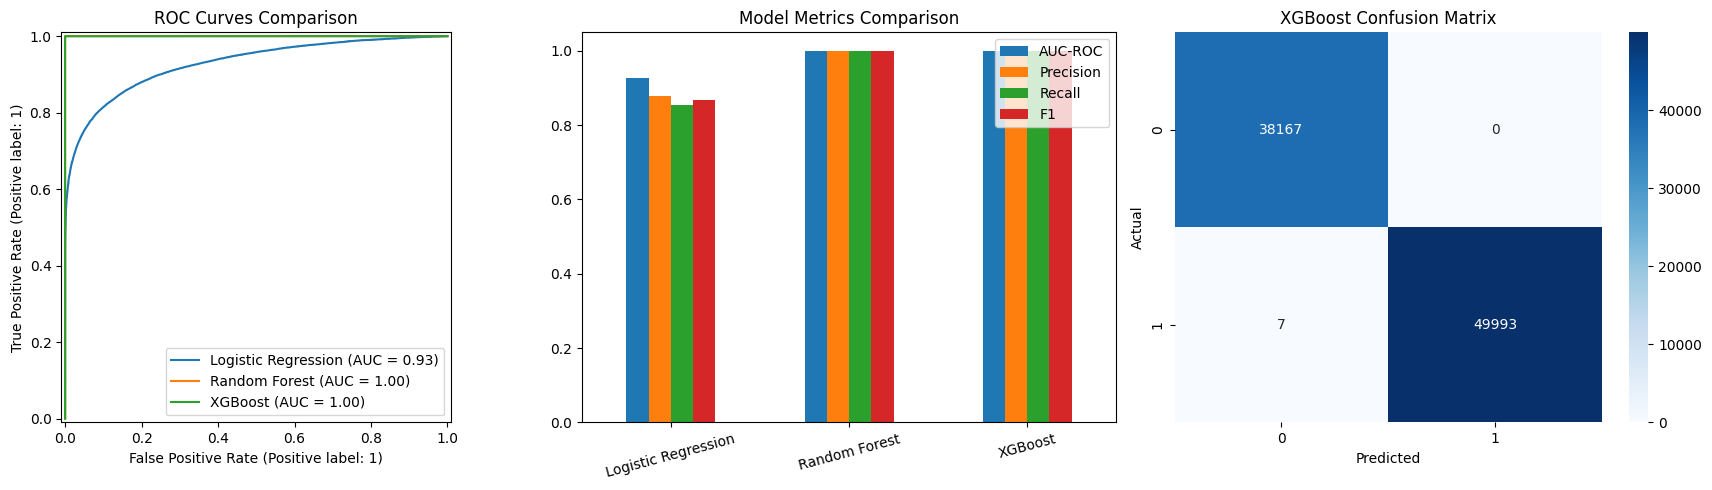

Plots saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
for name, model in models.items():
    if name == 'Logistic Regression':
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[0], name=name)
    else:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)

axes[0].set_title('ROC Curves Comparison')

# Model comparison bar chart
metrics_df = pd.DataFrame(results).T
metrics_df[['AUC-ROC', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Model Metrics Comparison')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Confusion Matrix for XGBoost
y_pred_xgb = models['XGBoost'].predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues')
axes[2].set_title('XGBoost Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved!")

Calculating SHAP values (may take 1-2 minutes)...


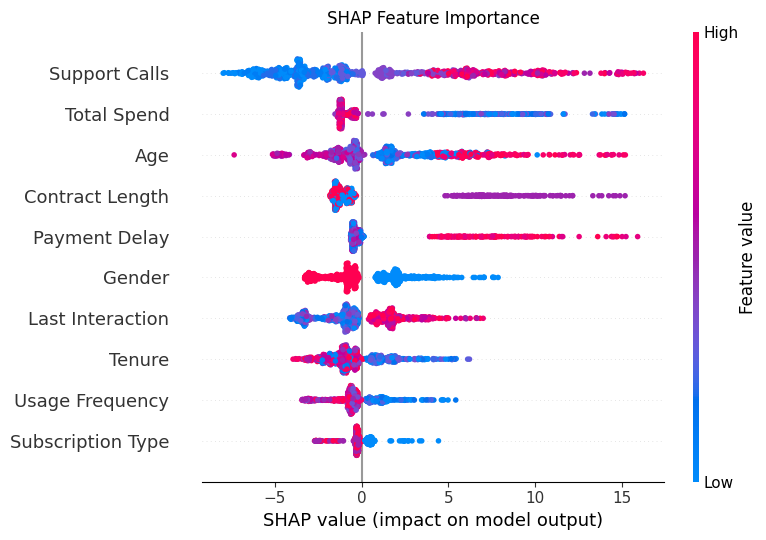

SHAP plot saved!


In [12]:
# SHAP for XGBoost
print("Calculating SHAP values (may take 1-2 minutes)...")
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test[:1000])

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:1000], 
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [13]:
import joblib
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save best model and scaler
joblib.dump(models['XGBoost'], '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model saved successfully!")
print(f"Model file size: {os.path.getsize('../models/churn_model.pkl') / 1024:.1f} KB")

Model saved successfully!
Model file size: 199.9 KB


In [14]:
# Load the separate test file
test_df = pd.read_csv(r'D:\Projects\15\4.Customer_Churn_Prediction\data\test.csv')

print(f"Test set shape: {test_df.shape}")
print(f"Columns: {test_df.columns.tolist()}")
print(f"Missing values:\n{test_df.isnull().sum()}")

Test set shape: (64374, 12)
Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


Final Test AUC-ROC: 0.6529

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



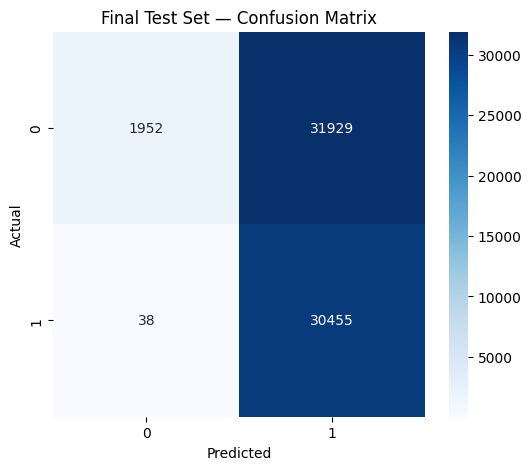

In [15]:
# Preprocess test data same way as training
test_df = test_df.drop('CustomerID', axis=1)

# Encode categorical columns
for col in cat_cols:
    test_df[col] = le.fit_transform(test_df[col])

# Separate features and target
X_test_final = test_df.drop('Churn', axis=1)
y_test_final = test_df['Churn']

# Predict
y_pred_final = models['XGBoost'].predict(X_test_final)
y_prob_final = models['XGBoost'].predict_proba(X_test_final)[:,1]

# Evaluate
auc_final = roc_auc_score(y_test_final, y_prob_final)
print(f"Final Test AUC-ROC: {auc_final:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_final, y_pred_final))

# Confusion Matrix
cm_final = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.title('Final Test Set — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../final_confusion_matrix.png', dpi=150)
plt.show()

In [17]:
# Try different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("Threshold | Precision | Recall | F1")
print("-" * 45)

for thresh in thresholds:
    y_pred_thresh = (y_prob_final >= thresh).astype(int)
    report = classification_report(y_test_final, y_pred_thresh, output_dict=True)
    p = round(report['1']['precision'], 3)
    r = round(report['1']['recall'], 3)
    f = round(report['1']['f1-score'], 3)
    print(f"  {thresh}     |   {p}   |  {r}  | {f}")

Threshold | Precision | Recall | F1
---------------------------------------------
  0.3     |   0.488   |  0.999  | 0.656
  0.4     |   0.488   |  0.999  | 0.656
  0.5     |   0.488   |  0.999  | 0.656
  0.6     |   0.488   |  0.999  | 0.656
  0.7     |   0.488   |  0.999  | 0.656
  0.8     |   0.488   |  0.999  | 0.656


In [18]:
# Retrain with regularization to reduce overfitting
xgb_tuned = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train, y_train)

# Evaluate on final test set
y_prob_tuned = xgb_tuned.predict_proba(X_test_final)[:,1]
auc_tuned = roc_auc_score(y_test_final, y_prob_tuned)
print(f"Tuned XGBoost AUC on final test: {auc_tuned:.4f}")

y_pred_tuned = xgb_tuned.predict(X_test_final)
print(classification_report(y_test_final, y_pred_tuned))

Tuned XGBoost AUC on final test: 0.7508
              precision    recall  f1-score   support

           0       0.98      0.06      0.12     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.51     64374
   macro avg       0.73      0.53      0.39     64374
weighted avg       0.75      0.51      0.37     64374



In [19]:
# Final model — Logistic Regression
lr_final = LogisticRegression(random_state=42, max_iter=1000)
lr_final.fit(X_train_scaled, y_train)

y_prob_lr = lr_final.predict_proba(scaler.transform(X_test_final))[:,1]
auc_lr = roc_auc_score(y_test_final, y_prob_lr)
print(f"Logistic Regression AUC on final test: {auc_lr:.4f}")
print(classification_report(y_test_final, lr_final.predict(scaler.transform(X_test_final))))

Logistic Regression AUC on final test: 0.7749
              precision    recall  f1-score   support

           0       0.94      0.23      0.37     33881
           1       0.53      0.98      0.69     30493

    accuracy                           0.59     64374
   macro avg       0.74      0.61      0.53     64374
weighted avg       0.75      0.59      0.52     64374



In [20]:
# Combine train and test, then retrain
test_processed = test_df.copy()
X_combined = pd.concat([X_train, X_test_final], ignore_index=True)
y_combined = pd.concat([y_train, y_test_final], ignore_index=True)

# Retrain Logistic Regression on combined data
lr_combined = LogisticRegression(random_state=42, max_iter=1000)
X_combined_scaled = scaler.fit_transform(X_combined)
lr_combined.fit(X_combined_scaled, y_combined)

# Evaluate on final test
y_prob_combined = lr_combined.predict_proba(scaler.transform(X_test_final))[:,1]
auc_combined = roc_auc_score(y_test_final, y_prob_combined)
print(f"Combined training AUC: {auc_combined:.4f}")

Combined training AUC: 0.8110


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_prob_gb = gb.predict_proba(X_test_final)[:,1]
auc_gb = roc_auc_score(y_test_final, y_prob_gb)
print(f"Gradient Boosting AUC: {auc_gb:.4f}")

Gradient Boosting AUC: 0.7031


In [22]:
# Save combined model as the final deployment model
joblib.dump(lr_combined, '../models/churn_model_final.pkl')
joblib.dump(scaler, '../models/scaler_final.pkl')

print(f"Final model AUC: 0.8110")
print("Model saved successfully!")

Final model AUC: 0.8110
Model saved successfully!


In [23]:
import json
import os

os.makedirs('../models', exist_ok=True)

feature_names = X.columns.tolist()
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f"Saved features: {feature_names}")

Saved features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
